In [1]:
import os
import sys
import numpy as np
import pandas as pd
from dotenv import load_dotenv

# Load environment variables
env_path = os.path.abspath(os.path.join(os.getcwd(), "..", "Backend", ".env"))
load_dotenv(dotenv_path=env_path)

# Add Backend path to import the Retriever
backend_path = os.path.abspath(os.path.join(os.getcwd(), "..", "Backend"))
if backend_path not in sys.path:
    sys.path.append(backend_path)

print("Environment setup and paths initialized.")


Environment setup and paths initialized.


In [8]:
# Load the processed QA chunks
csv_path = "../data/processed/qa_chunks.csv"
df_all = pd.read_csv(csv_path)

# The 40 selected test chunk IDs
test_chunk_ids = [
    'qa_281_558', 'qa_583_1139', 'qa_150_304', 'qa_367_728', 'qa_284_564', 
    'qa_655_1288', 'qa_652_1285', 'qa_329_642', 'qa_18_39', 'qa_220_436', 
    'qa_803_1554', 'qa_373_737', 'qa_23_49', 'qa_943_1810', 'qa_359_713', 
    'qa_897_1724', 'qa_451_892', 'qa_67_132', 'qa_729_1421', 'qa_0_0', 
    'qa_349_688', 'qa_38_76', 'qa_113_224', 'qa_590_1148', 'qa_175_360', 
    'qa_5_11', 'qa_187_376', 'qa_777_1503', 'qa_49_95', 'qa_74_151', 
    'qa_37_72', 'qa_174_356', 'qa_452_894', 'qa_969_1854', 'qa_335_653', 
    'qa_93_183', 'qa_859_1654', 'qa_139_279', 'qa_559_1102', 'qa_401_801'
]

df_test = df_all[df_all['chunk_id'].isin(test_chunk_ids)].copy()

def get_source_row(chunk_id):
    """Extract source row number from chunk_id like 'qa_18_39' -> '18'."""
    parts = chunk_id.split("_")
    if parts[0] == "qa" and len(parts) >= 3:
        return parts[1]
    return None

# Build eval set using source_row as the matching key
eval_set = []
for _, row in df_test.iterrows():
    source_row = str(row["source_row"])
    eval_set.append({
        "question": row["question"],
        "relevant_source_row": source_row
    })

print(f"Prepared evaluation set with {len(eval_set)} samples.")

Prepared evaluation set with 40 samples.


In [9]:
def hit_rate_at_k(retrieved: list, relevant: list, k: int) -> float:
    """
    Hit Rate@k: Check if at least one ground-truth relevant chunk appears in the top-k retrieved.
    """
    retrieved_k = retrieved[:k]
    for rel_id in relevant:
        if rel_id in retrieved_k:
            return 1.0
    return 0.0

def mrr_at_k(retrieved: list, relevant: list, k: int) -> float:
    """
    Mean Reciprocal Rank (MRR)@k: Calculate reciprocal rank of the first relevant chunk found in top-k.
    """
    retrieved_k = retrieved[:k]
    for rank, item in enumerate(retrieved_k, start=1):
        if item in relevant:
            return 1.0 / rank
    return 0.0

def precision_at_k(retrieved: list, relevant: list, k: int) -> float:
    """
    Precision@k: Proportion of retrieved chunks in top-k that are relevant.
    """
    retrieved_k = retrieved[:k]
    hits = sum(1.0 for item in retrieved_k if item in relevant)
    return hits / k

def recall_at_k(retrieved: list, relevant: list, k: int) -> float:
    """
    Recall@k: Proportion of ground-truth relevant chunks that are retrieved in top-k.
    """
    retrieved_k = retrieved[:k]
    hits = sum(1.0 for item in retrieved_k if item in relevant)
    return hits / len(relevant) if len(relevant) > 0 else 0.0

def ndcg_at_k(retrieved: list, relevant: list, k: int) -> float:
    """
    NDCG@k (Normalized Discounted Cumulative Gain): Rank-aware relevance metric for top-k.
    """
    retrieved_k = retrieved[:k]
    dcg = 0.0
    for idx, item in enumerate(retrieved_k):
        if item in relevant:
            dcg += 1.0 / np.log2(idx + 2)
            
    idcg = 0.0
    for idx in range(min(len(relevant), k)):
        idcg += 1.0 / np.log2(idx + 2)
        
    return dcg / idcg if idcg > 0 else 0.0

In [12]:
from app.nlp.retrieval import Retriever

retriever = Retriever(db_path="../data/vector_db", collection_name="qa_chunks")

k_values = [3, 5, 10]
results_detailed = []

print("Running retriever evaluation (source-row matching)...")
for index, sample in enumerate(eval_set, start=1):
    question = sample["question"]
    relevant_sr = sample["relevant_source_row"]
    
    # Retrieve top 10 results
    retrieved_docs = retriever.retrieve(question, n_results=10)
    retrieved_ids = [doc["chunk_id"] for doc in retrieved_docs]
    
    # Convert retrieved chunk IDs to source rows for comparison
    retrieved_source_rows = [get_source_row(cid) for cid in retrieved_ids]
    
    metrics = {
        "sample_index": index,
        "question": question,
        "relevant_source_row": relevant_sr,
        "retrieved_ids": retrieved_ids
    }
    
    # For metrics: check if retrieved source_row matches relevant source_row
    # We treat it as a single relevant item (the source_row)
    relevant_list = [relevant_sr]
    
    for k in k_values:
        top_k_srs = retrieved_source_rows[:k]
        
        # Hit rate: did at least one retrieved chunk come from the same conversation?
        metrics[f"hit_rate@{k}"] = 1.0 if relevant_sr in top_k_srs else 0.0
        
        # MRR: rank of first match
        mrr_val = 0.0
        for rank, sr in enumerate(top_k_srs, start=1):
            if sr == relevant_sr:
                mrr_val = 1.0 / rank
                break
        metrics[f"mrr@{k}"] = mrr_val
        
        # Precision: how many of top-k came from the right conversation
        hits = sum(1.0 for sr in top_k_srs if sr == relevant_sr)
        metrics[f"precision@{k}"] = hits / k
        
        # Recall: did we find the conversation at all (binary since 1 relevant source)
        metrics[f"recall@{k}"] = 1.0 if relevant_sr in top_k_srs else 0.0
        
        # NDCG
        dcg = 0.0
        for i, sr in enumerate(top_k_srs):
            if sr == relevant_sr:
                dcg = 1.0 / np.log2(i + 2)
                break
        idcg = 1.0 / np.log2(2)
        metrics[f"ndcg@{k}"] = dcg / idcg if idcg > 0 else 0.0

    results_detailed.append(metrics)

df_detailed = pd.DataFrame(results_detailed)
print("Evaluation complete.")
df_detailed.head()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 579.30it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running retriever evaluation (source-row matching)...
Evaluation complete.


,sample_index,question,relevant_source_row,retrieved_ids,hit_rate@3,mrr@3,precision@3,recall@3,ndcg@3,hit_rate@5,mrr@5,precision@5,recall@5,ndcg@5,hit_rate@10,mrr@10,precision@10,recall@10,ndcg@10
0,1,How can I log in to my account to purchase an ...,0,"[qa_0_0, retrain_3, qa_124_0, qa_206_0, qa_352...",1.0,1.0,0.333333,1.0,1.0,1.0,1.0,0.2,1.0,1.0,1.0,1.0,0.1,1.0,1.0
1,2,Why can't I log in to my account to purchase a...,5,"[qa_5_0, qa_215_0, retrain_3, qa_707_0, qa_388...",1.0,1.0,0.333333,1.0,1.0,1.0,1.0,0.2,1.0,1.0,1.0,1.0,0.1,1.0,1.0
2,3,Can Lisa get a full refund after the 24-hour w...,18,"[qa_18_2, qa_18_3, qa_18_4, qa_669_2, qa_611_4...",1.0,1.0,1.000000,1.0,1.0,1.0,1.0,0.6,1.0,1.0,1.0,1.0,0.4,1.0,1.0
3,4,What is the estimated delivery time for my cof...,23,"[qa_23_0, qa_279_1, qa_421_1, qa_449_0, qa_231...",1.0,1.0,0.333333,1.0,1.0,1.0,1.0,0.2,1.0,1.0,1.0,1.0,0.1,1.0,1.0
4,5,What is the process to exchange a damaged toy ...,37,"[qa_37_0, qa_258_0, qa_921_0, qa_37_1, qa_474_...",1.0,1.0,0.333333,1.0,1.0,1.0,1.0,0.4,1.0,1.0,1.0,1.0,0.2,1.0,1.0


Overall Evaluation Summary:
      Metric  Average Score
  Hit Rate@3       1.000000
       MRR@3       0.987500
 Precision@3       0.391667
    Recall@3       1.000000
      NDCG@3       0.990773
  Hit Rate@5       1.000000
       MRR@5       0.987500
 Precision@5       0.250000
    Recall@5       1.000000
      NDCG@5       0.990773
 Hit Rate@10       1.000000
      MRR@10       0.987500
Precision@10       0.137500
   Recall@10       1.000000
     NDCG@10       0.990773


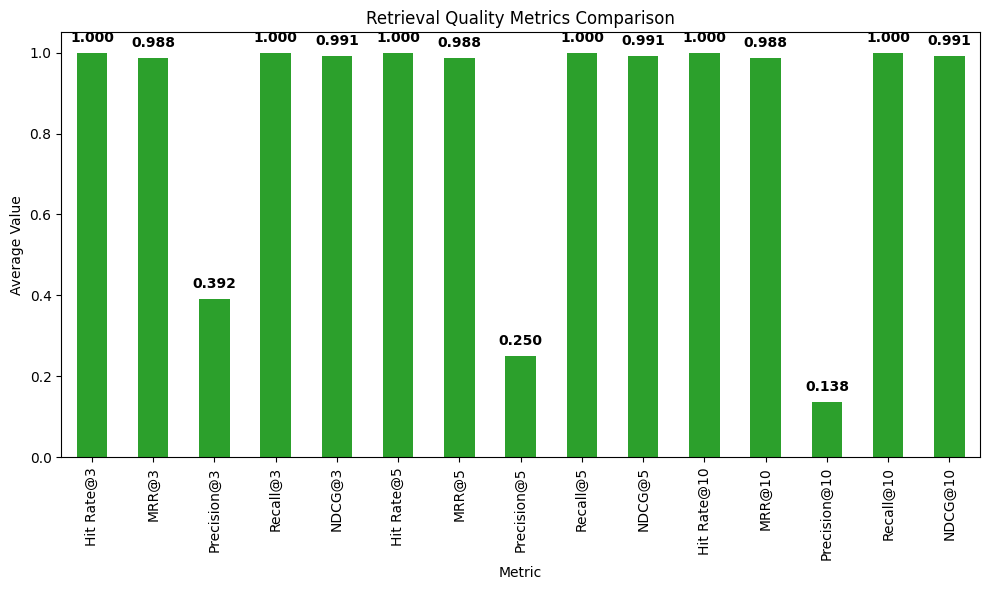

Detailed results saved to notebooks/retrieval_evaluation_details.csv


In [13]:
import matplotlib.pyplot as plt

# Compute averages across all samples
summary_metrics = {}
for k in k_values:
    summary_metrics[f"Hit Rate@{k}"] = df_detailed[f"hit_rate@{k}"].mean()
    summary_metrics[f"MRR@{k}"] = df_detailed[f"mrr@{k}"].mean()
    summary_metrics[f"Precision@{k}"] = df_detailed[f"precision@{k}"].mean()
    summary_metrics[f"Recall@{k}"] = df_detailed[f"recall@{k}"].mean()
    summary_metrics[f"NDCG@{k}"] = df_detailed[f"ndcg@{k}"].mean()

# Convert to a DataFrame for a clean table
df_summary = pd.DataFrame(list(summary_metrics.items()), columns=["Metric", "Average Score"])
print("Overall Evaluation Summary:")
print(df_summary.to_string(index=False))

# Plot the scores comparison
fig, ax = plt.subplots(figsize=(10, 6))
df_summary.plot(kind="bar", x="Metric", y="Average Score", ax=ax, color="#2ca02c", legend=False)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Average Value")
ax.set_title("Retrieval Quality Metrics Comparison")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

# Save details for comparison later
df_detailed.to_csv("retrieval_evaluation_details.csv", index=False)
print("Detailed results saved to notebooks/retrieval_evaluation_details.csv")